In [22]:
using Pkg
# Pkg.add("GLMakie")
# Pkg.add("KernelDensity")
# Pkg.add("HypothesisTests")
# Pkg.add("Distributions")

   Resolving package versions...
    Updating `~/.julia/environments/v1.10/Project.toml`
  [31c24e10] + Distributions v0.25.122
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


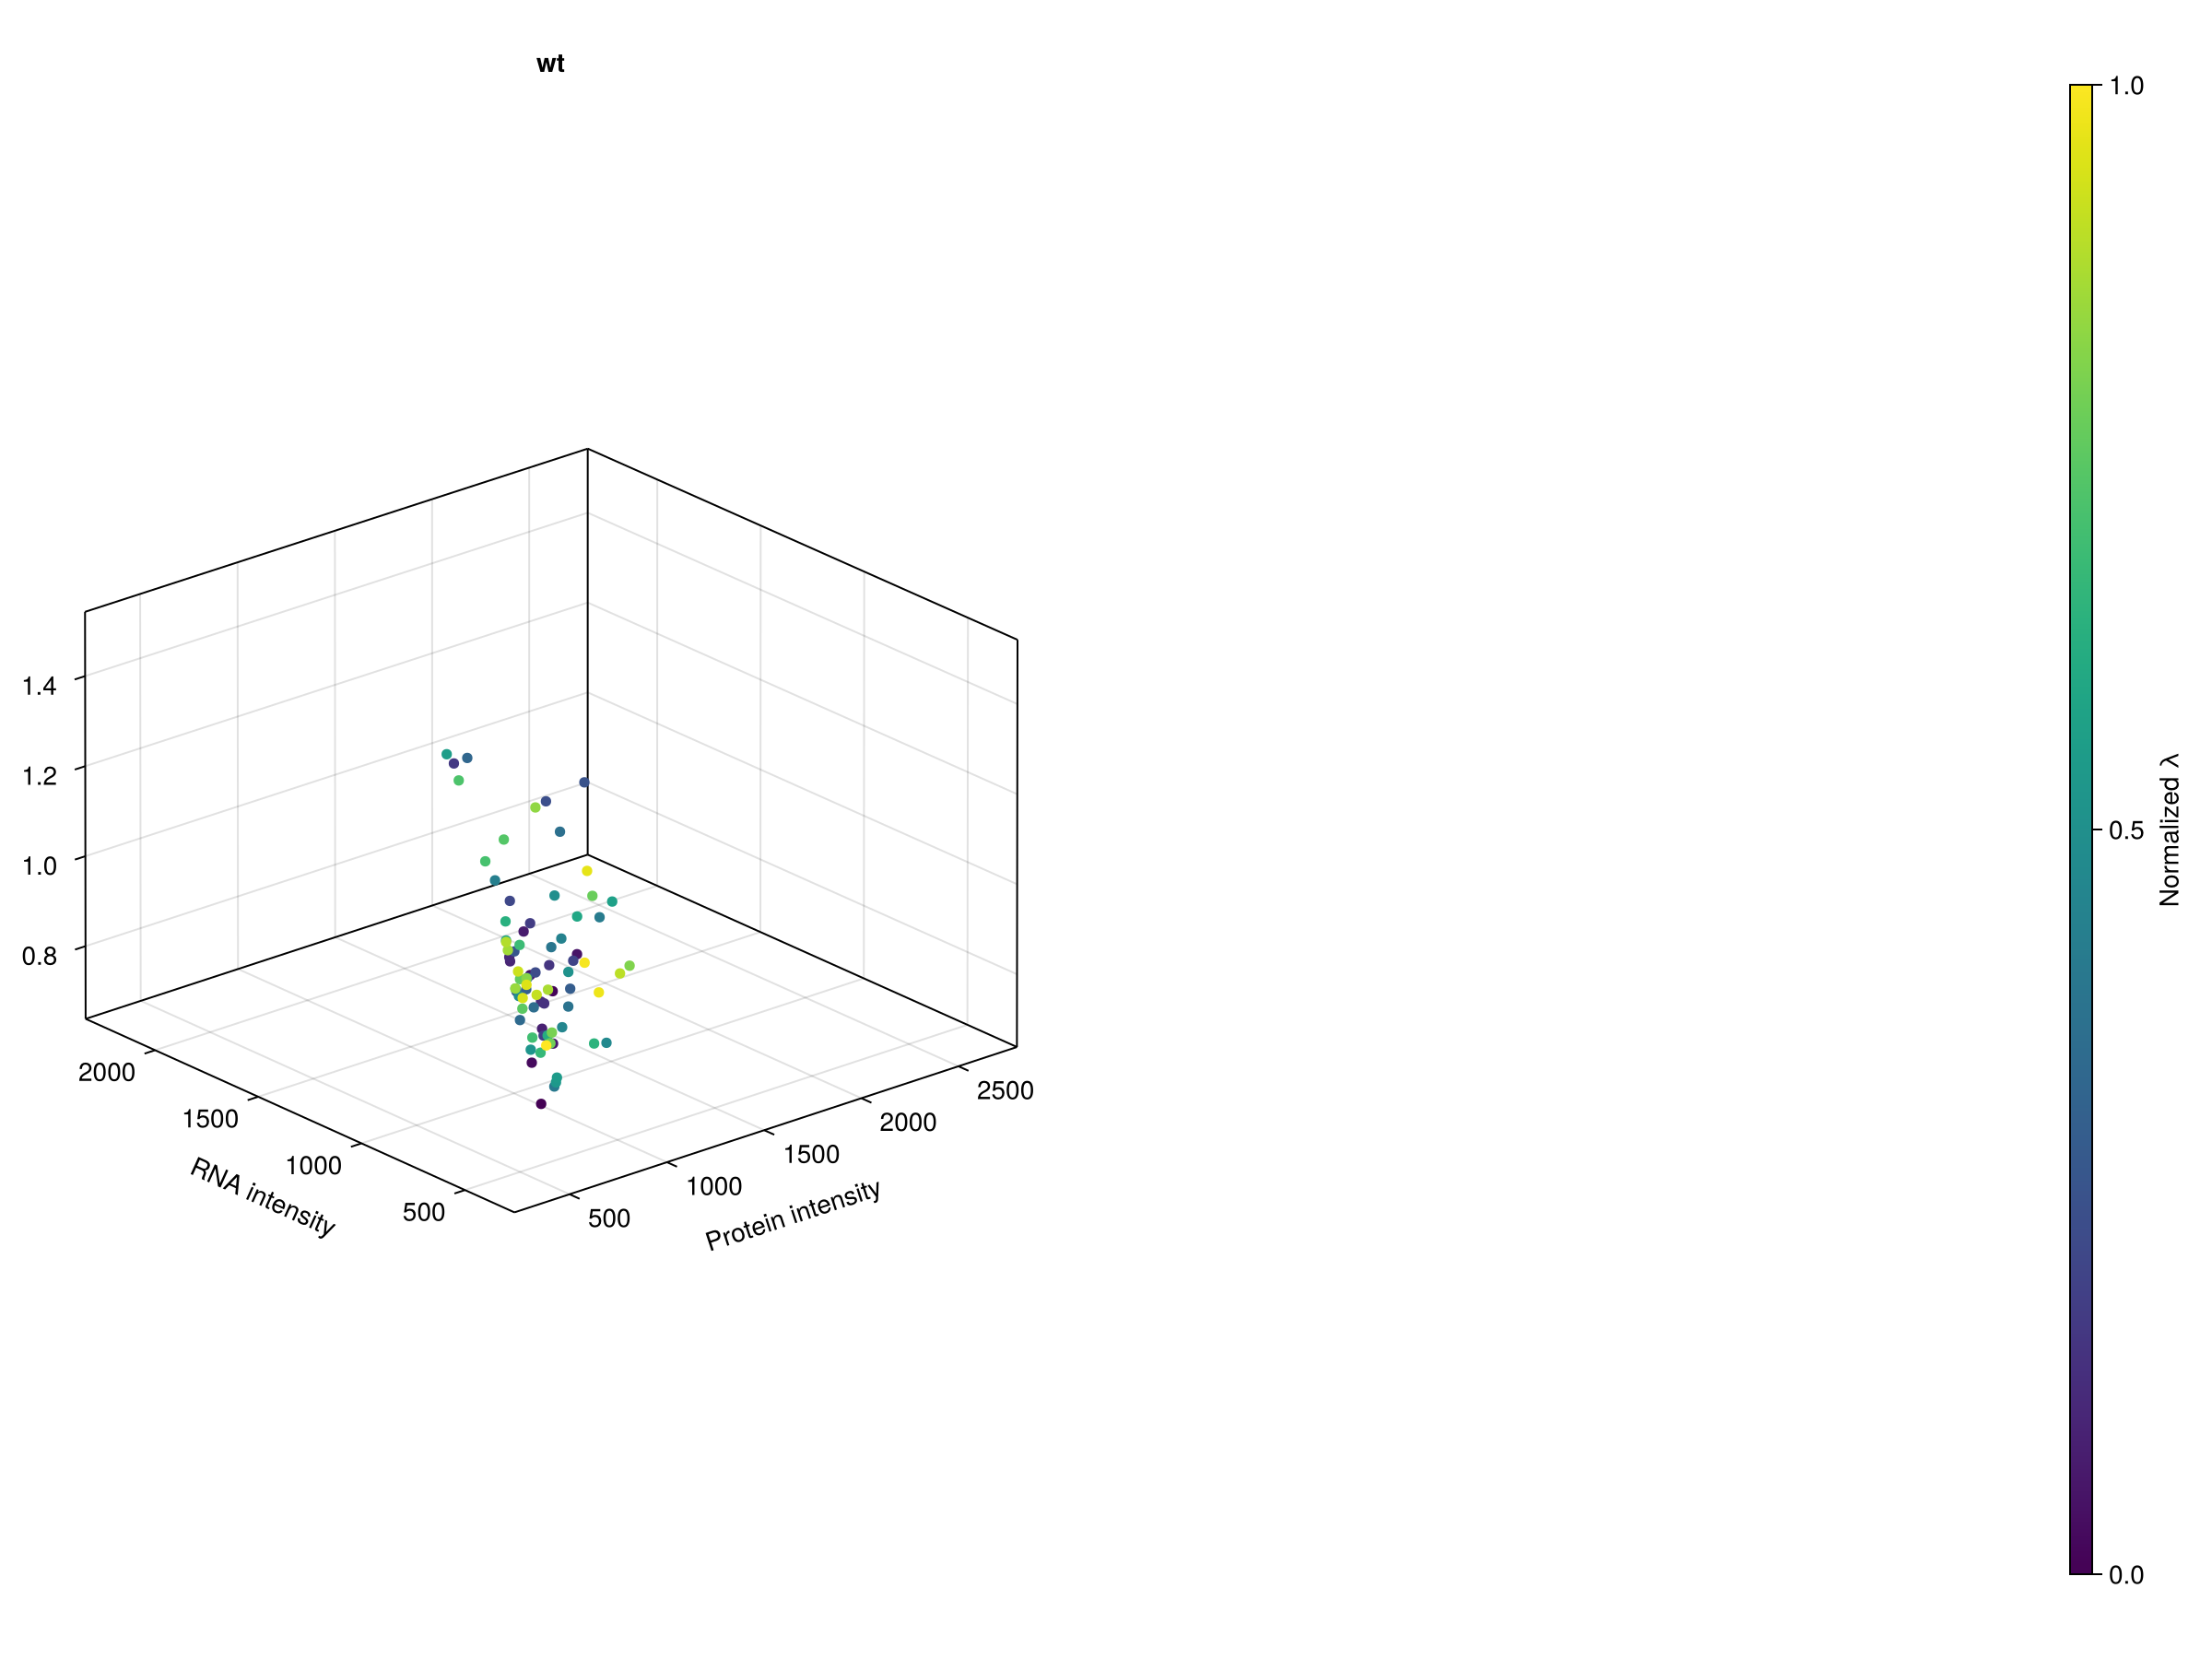

In [33]:
using XLSX, DataFrames, CairoMakie

filename = "Raman_data.xlsx"
sheetnames = ["wt"] #, "rtcA", "rtcB", "rtcR"]

function extract_rna_protein_ratio(df::DataFrame)
    biomolecules = [lowercase(strip(String(x))) for x in df[:, 1]]
    idx_protein = findfirst(==("prt"), biomolecules)
    idx_rna = findfirst(==("rna"), biomolecules)
    if any(==(nothing), [idx_protein, idx_rna])
        @warn "Missing biomolecule rows"
        return [], [], []
    end
    cols = names(df)[2:end]
    protein_vals = [df[idx_protein, c] for c in cols]
    rna_vals = [df[idx_rna, c] for c in cols]
    ratio_vals = rna_vals ./ protein_vals
    return protein_vals, rna_vals, ratio_vals
end

xf = XLSX.readxlsx(filename)
data = Dict()

for sheet in sheetnames
    ws = xf[sheet]
    df = DataFrame(XLSX.gettable(ws))
    data[sheet] = extract_rna_protein_ratio(df)
end

fig = Figure(size = (1200, 900))
colormap = :viridis

for (i, sheet) in enumerate(sheetnames)
    protein_vals, rna_vals, ratio_vals = data[sheet]
    if isempty(protein_vals)
        @warn "Skipping empty sheet $sheet"
        continue
    end
    n = length(protein_vals)
    growth_rates = LinRange(0, 1, n)  # placeholder, replace with real λ later
    λnorm = (growth_rates .- minimum(growth_rates)) ./ (maximum(growth_rates) - minimum(growth_rates))

    row = div(i - 1, 2) + 1
    col = mod1(i, 2)
    ax = Axis3(fig[row, col],
        title = "$sheet",
        xlabel = "Protein intensity",
        ylabel = "RNA intensity",
        zlabel = "RNA/Protein ratio")
    scatter!(ax, protein_vals, rna_vals, ratio_vals,
        markersize = 8, color = λnorm, colormap = colormap)
end

Colorbar(fig[1, 3], colormap = colormap, limits = (0, 1), label = "Normalized λ")
fig
# save("Raman_3D_panels.png", fig)


In [3]:
using XLSX, DataFrames, CairoMakie

filename = "Raman_data.xlsx"
sheetnames = ["wt"]

function extract_rna_protein_ratio(df::DataFrame)
    biomolecules = [lowercase(strip(String(x))) for x in df[:, 1]]
    idx_protein = findfirst(==("prt"), biomolecules)
    idx_rna = findfirst(==("rna"), biomolecules)
    if any(==(nothing), [idx_protein, idx_rna])
        @warn "Missing biomolecule rows"
        return [], [], []
    end
    cols = names(df)[2:end]
    protein_vals = [df[idx_protein, c] for c in cols]
    rna_vals = [df[idx_rna, c] for c in cols]
    ratio_vals = rna_vals ./ protein_vals
    return protein_vals, rna_vals, ratio_vals
end

# --- Load data ---
xf = XLSX.readxlsx(filename)
ws = xf["wt"]
df = DataFrame(XLSX.gettable(ws))
protein_vals, rna_vals, ratio_vals = extract_rna_protein_ratio(df)

# --- 2D Projection plots ---
fig = Figure(size = (1200, 400))

# 1️⃣ RNA vs Protein
ax1 = Axis(fig[1, 1],
    title = "RNA vs Protein (Wild Type)",
    xlabel = "Protein intensity",
    ylabel = "RNA intensity")
scatter!(ax1, protein_vals, rna_vals; markersize = 10, color = :steelblue)
lines!(ax1, [minimum(protein_vals), maximum(protein_vals)],
             [minimum(protein_vals), maximum(protein_vals)],
             color = (:black, 0.5), linestyle = :dash, label = "x=y")
axislegend(ax1)

# 2️⃣ Ratio vs Protein
ax2 = Axis(fig[1, 2],
    title = "RNA/Protein ratio vs Protein",
    xlabel = "Protein intensity",
    ylabel = "RNA/Protein ratio")
scatter!(ax2, protein_vals, ratio_vals; color = :darkorange, markersize = 10)
hlines!(ax2, [mean(ratio_vals)]; color = (:black, 0.4), linestyle = :dash, label = "mean ratio")
axislegend(ax2)

# 3️⃣ Ratio vs RNA
ax3 = Axis(fig[1, 3],
    title = "RNA/Protein ratio vs RNA",
    xlabel = "RNA intensity",
    ylabel = "RNA/Protein ratio")
scatter!(ax3, rna_vals, ratio_vals; color = :seagreen, markersize = 10)
hlines!(ax3, [mean(ratio_vals)]; color = (:black, 0.4), linestyle = :dash, label = "mean ratio")
axislegend(ax3)

fig
save("WT_Raman_2D_views.png", fig)


In [32]:
using HypothesisTests

# Correlations
test_rna_prot  = CorrelationTest(rna_vals, protein_vals)
test_rna_ratio = CorrelationTest(rna_vals, ratio_vals)
test_prot_ratio = CorrelationTest(protein_vals, ratio_vals)

# Extract r and p
r1, p1 = test_rna_prot.r,  pvalue(test_rna_prot)
r2, p2 = test_rna_ratio.r, pvalue(test_rna_ratio)
r3, p3 = test_prot_ratio.r, pvalue(test_prot_ratio)

println("RNA vs Protein:   Correlation = $(round(r1, digits=3)), p = $(round(p1, sigdigits=3))")
println("RNA vs Ratio:     Correlation = $(round(r2, digits=3)), p = $(round(p2, sigdigits=3))")
println("Protein vs Ratio: Correlation = $(round(r3, digits=3)), p = $(round(p3, sigdigits=3))")


RNA vs Protein:   Correlation = 0.951, p = 2.39e-41
RNA vs Ratio:     Correlation = -0.258, p = 0.0209
Protein vs Ratio: Correlation = -0.516, p = 9.68e-7


In [15]:
using XLSX, DataFrames, CairoMakie, Statistics, KernelDensity

filename = "Raman_data.xlsx"
sheetnames = ["wt", "rtcA", "rtcB", "rtcR"]
colors = Dict(
    "wt" => (:gray, :gray),
    "rtcA" => (:lightcoral, :darkred),
    "rtcB" => (:plum, :purple),
    "rtcR" => (:turquoise, :teal)
)
# dashed line positions (optional reference, e.g. population mean)
ref_mean = 1.0

function get_ratios(ws)
    df = DataFrame(XLSX.gettable(ws))
    biomolecules = [lowercase(strip(String(x))) for x in df[:, 1]]
    idx_p, idx_r = findfirst(==("prt"), biomolecules), findfirst(==("rna"), biomolecules)
    cols = names(df)[2:end]
    protein = [df[idx_p, c] for c in cols]
    rna = [df[idx_r, c] for c in cols]
    rna ./ protein
end

xf = XLSX.readxlsx(filename)
ratios = Dict(sheet => get_ratios(xf[sheet]) for sheet in sheetnames)

fig = Figure(size = (500, 700))
for (i, sheet) in enumerate(sheetnames)
    col_fill, col_line = colors[sheet]
    ax = Axis(fig[i, 1];
        ylabel = "pdf",
        xlabel = (i == length(sheetnames) ? "RNA/Protein" : ""),
        title = (i == 1 ? "E" : ""),
        yticksvisible = false,
        xticklabelsize = 12,
        yticklabelsize = 10,
        titlealign = :left
    )

    vals = ratios[sheet]
    n = length(vals)

    # Histogram
    hist!(ax, vals; bins = 20, normalization = :pdf, color = (col_fill, 0.5), strokewidth = 0)

    # KDE overlay
    kd = kde(vals)
    lines!(ax, kd.x, kd.density; color = col_line, linewidth = 2)

    # Mean & reference lines
    vlines!(ax, [mean(vals)]; color = :orange, linestyle = :dash, linewidth = 2)
    vlines!(ax, [ref_mean]; color = :dodgerblue, linestyle = :dash, linewidth = 2)

    # Annotation box
    box_text = sheet == "wt" ? "WT" : "Δ$(sheet)"
    text!(ax, "$(box_text)\n n = $n";
          position = (1.3, maximum(kd.density)*0.7),
          align = (:left, :center), fontsize = 12, color = col_line)
end

fig
save("FigureE_replicated.png", fig)


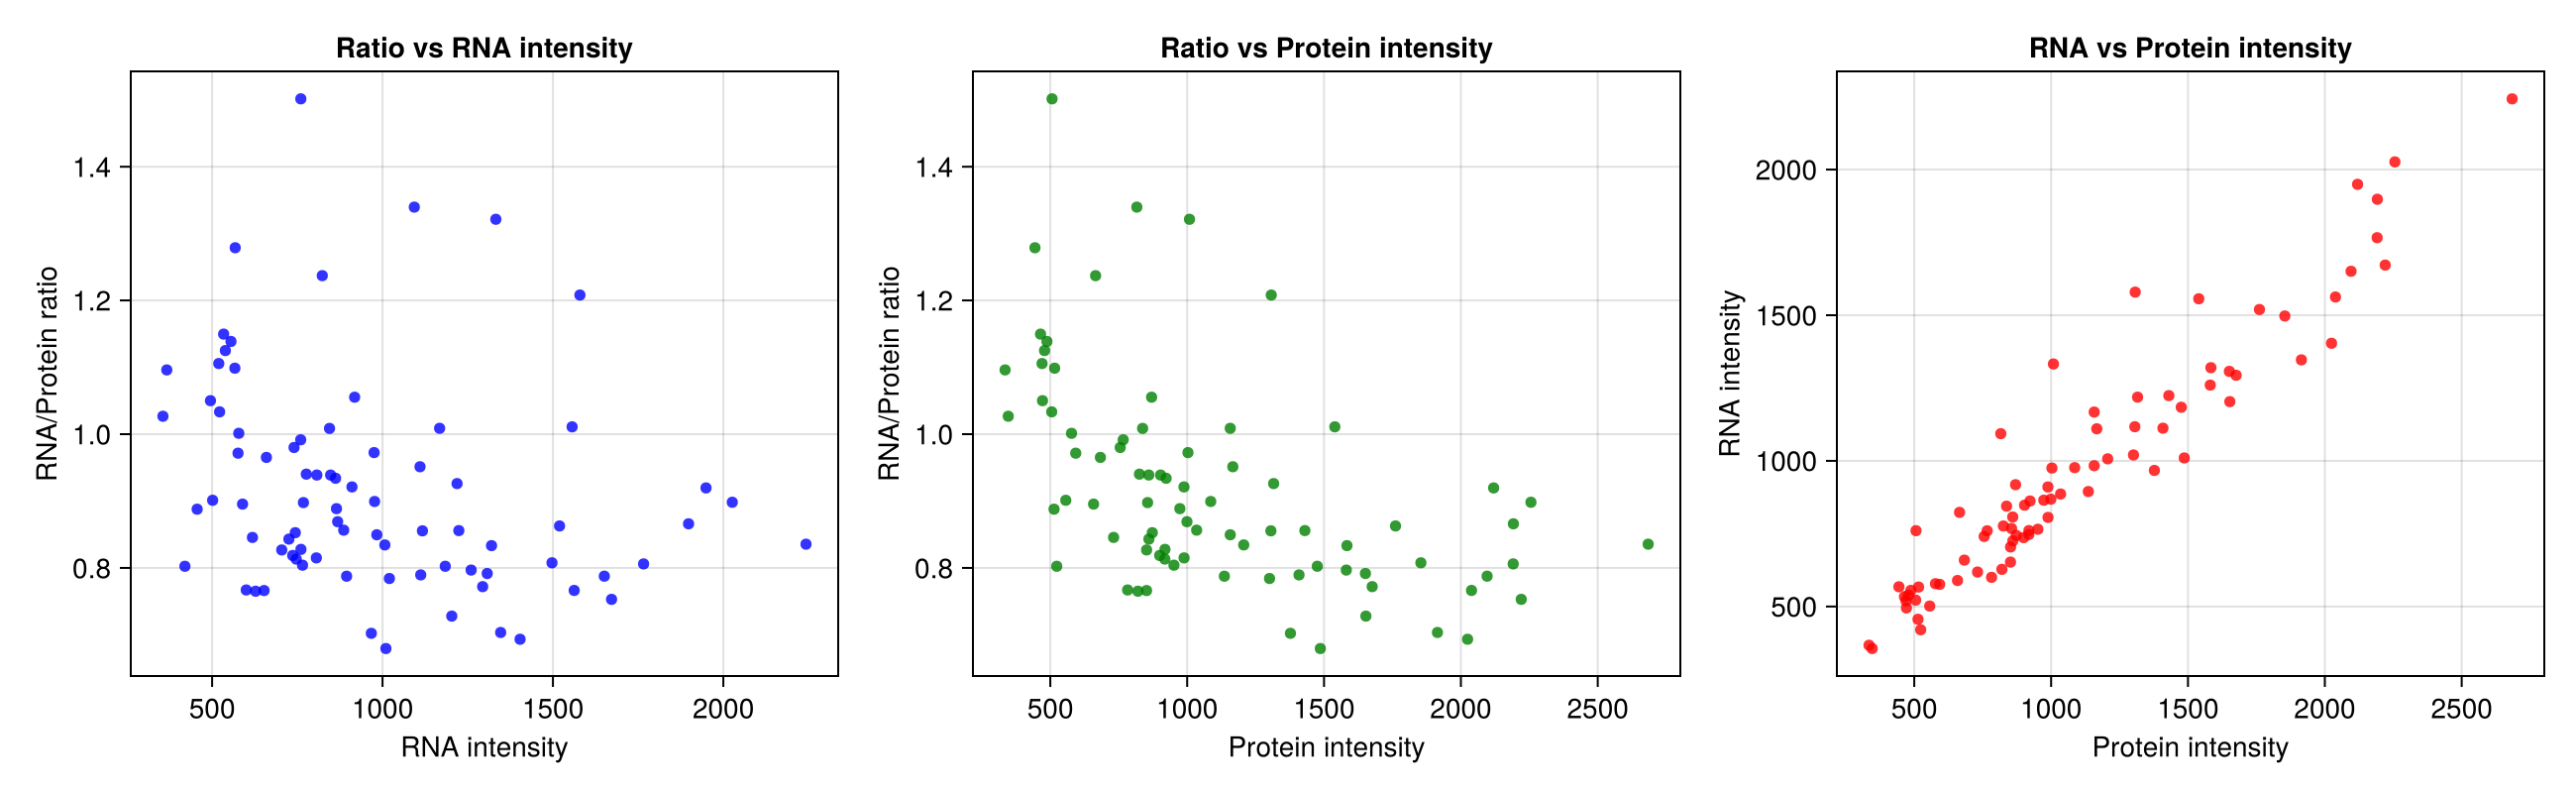

In [6]:
fig = Figure(size = (1300, 400))
ax1 = Axis(fig[1, 1], xlabel = "RNA intensity", ylabel = "RNA/Protein ratio", title = "Ratio vs RNA intensity")
scatter!(ax1, rna_vals, ratio_vals; color = :blue, markersize = 8, alpha = 0.8)

ax2 = Axis(fig[1, 2], xlabel = "Protein intensity", ylabel = "RNA/Protein ratio", title = "Ratio vs Protein intensity")
scatter!(ax2, protein_vals, ratio_vals; color = :green, markersize = 8, alpha = 0.8)

ax3 = Axis(fig[1, 3], xlabel = "Protein intensity", ylabel = "RNA intensity", title = "RNA vs Protein intensity")
scatter!(ax3, protein_vals, rna_vals; color = :red, markersize = 8, alpha = 0.8)

fig


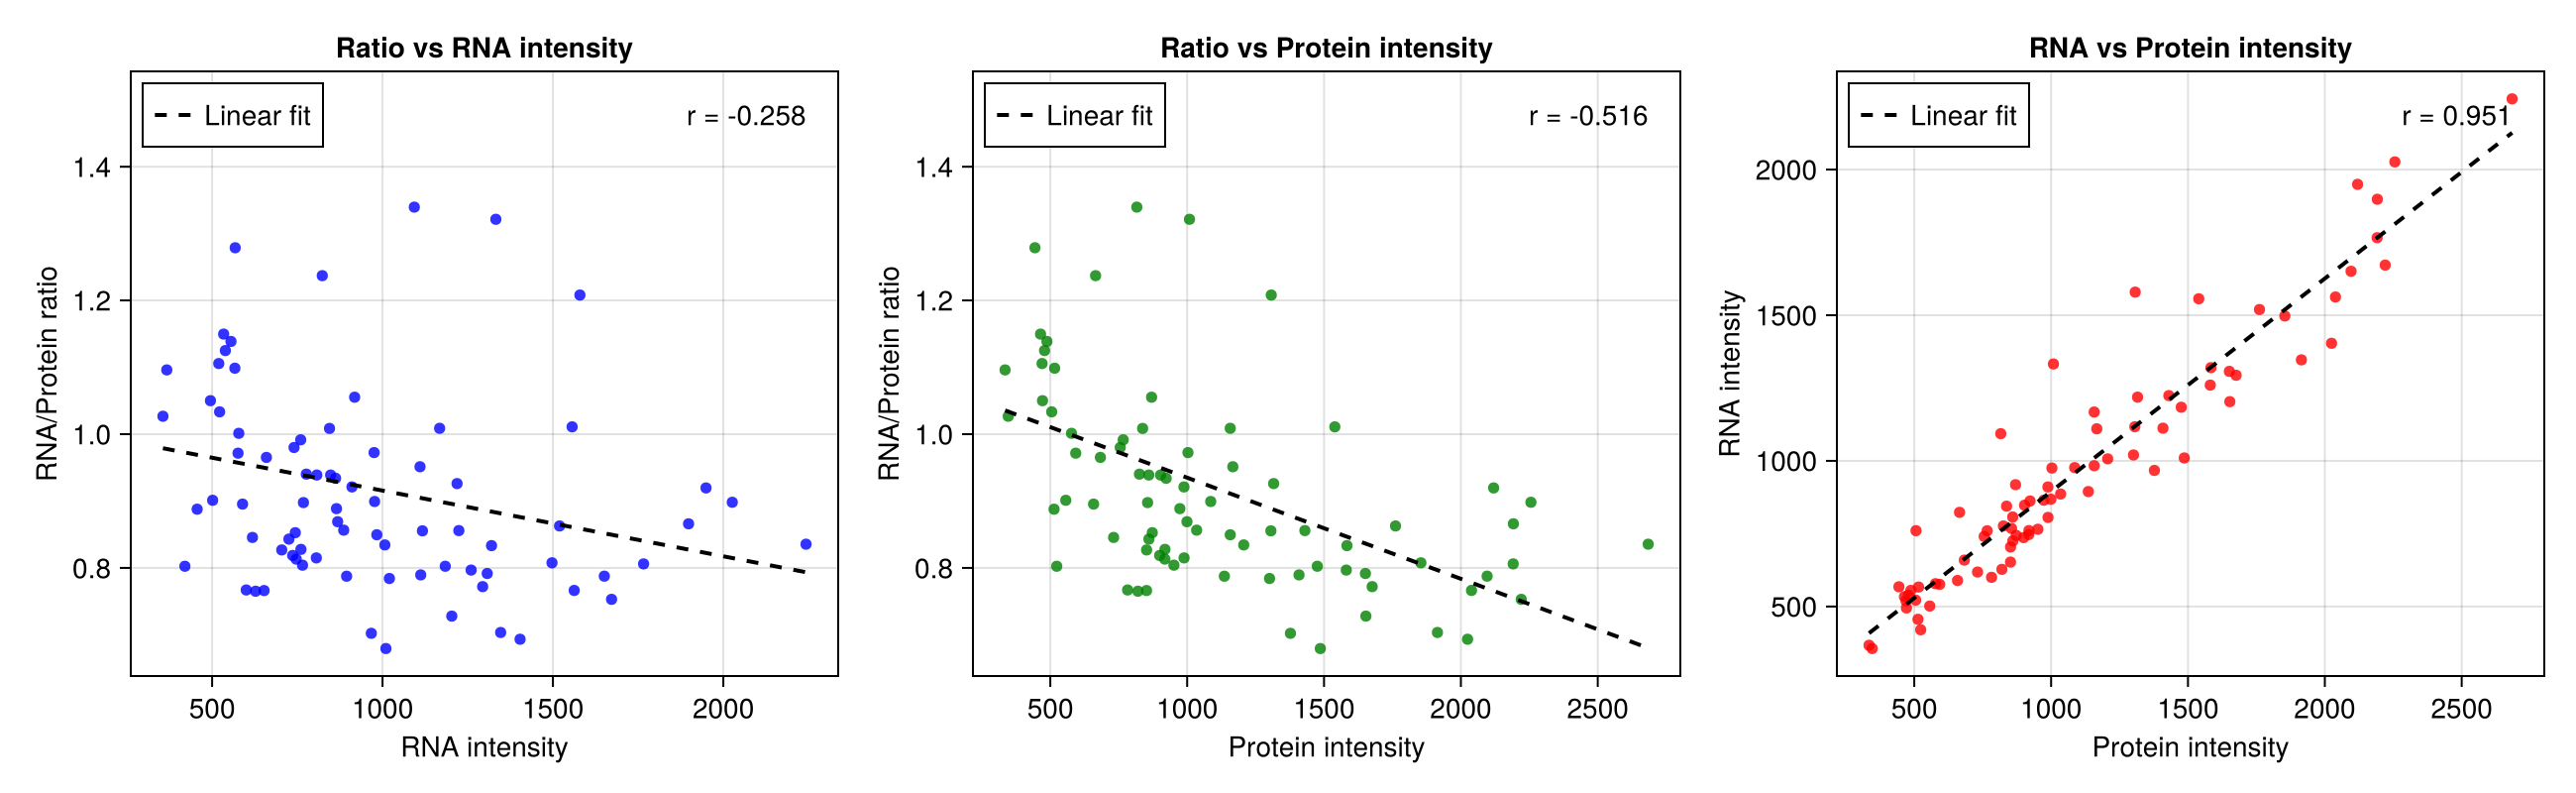

In [5]:
using CairoMakie, Statistics

# rna_vals, protein_vals, ratio_vals assumed already defined (Vectors of equal length)

# ---- tiny helper for simple linear regression y ≈ m*x + b
function linreg(x::AbstractVector, y::AbstractVector)
    xm, ym = mean(x), mean(y)
    m = sum((x .- xm) .* (y .- ym)) / sum((x .- xm).^2)
    b = ym - m * xm
    return m, b
end

# ---- fits + correlations for each subplot
m1, b1 = linreg(rna_vals,     ratio_vals);  r1 = cor(rna_vals,     ratio_vals)   # Ratio vs RNA
m2, b2 = linreg(protein_vals, ratio_vals);  r2 = cor(protein_vals, ratio_vals)   # Ratio vs Protein
m3, b3 = linreg(protein_vals, rna_vals);    r3 = cor(protein_vals, rna_vals)     # RNA vs Protein

fig = Figure(size = (1300, 400))

# 1) Ratio vs RNA
ax1 = Axis(fig[1, 1], xlabel = "RNA intensity", ylabel = "RNA/Protein ratio",
           title = "Ratio vs RNA intensity")
scatter!(ax1, rna_vals, ratio_vals; color = :blue, markersize = 8, alpha = 0.8)
x1 = range(minimum(rna_vals),    stop = maximum(rna_vals),    length = 200)
lines!(ax1, x1, m1 .* x1 .+ b1; color=:black, linewidth=2, linestyle=:dash, label="Linear fit")
text!(ax1, maximum(rna_vals), maximum(ratio_vals),
      text = "r = $(round(r1, digits=3))", align = (:right, :top), fontsize = 14)
axislegend(ax1, position=:lt)

# 2) Ratio vs Protein
ax2 = Axis(fig[1, 2], xlabel = "Protein intensity", ylabel = "RNA/Protein ratio",
           title = "Ratio vs Protein intensity")
scatter!(ax2, protein_vals, ratio_vals; color = :green, markersize = 8, alpha = 0.8)
x2 = range(minimum(protein_vals), stop = maximum(protein_vals), length = 200)
lines!(ax2, x2, m2 .* x2 .+ b2; color=:black, linewidth=2, linestyle=:dash, label="Linear fit")
text!(ax2, maximum(protein_vals), maximum(ratio_vals),
      text = "r = $(round(r2, digits=3))", align = (:right, :top), fontsize = 14)
axislegend(ax2, position=:lt)

# 3) RNA vs Protein
ax3 = Axis(fig[1, 3], xlabel = "Protein intensity", ylabel = "RNA intensity",
           title = "RNA vs Protein intensity")
scatter!(ax3, protein_vals, rna_vals; color = :red, markersize = 8, alpha = 0.8)
x3 = range(minimum(protein_vals), stop = maximum(protein_vals), length = 200)
lines!(ax3, x3, m3 .* x3 .+ b3; color=:black, linewidth=2, linestyle=:dash, label="Linear fit")
text!(ax3, maximum(protein_vals), maximum(rna_vals),
      text = "r = $(round(r3, digits=3))", align = (:right, :top), fontsize = 14)
axislegend(ax3, position=:lt)

fig


In [26]:
using Statistics
r_rna_ratio = cor(rna_vals, ratio_vals)
r_prot_ratio = cor(protein_vals, ratio_vals)
r_rna_prot   = cor(rna_vals, protein_vals)

println("Correlation (RNA vs Ratio):  ", round(r_rna_ratio, digits=3))
println("Correlation (Protein vs Ratio): ", round(r_prot_ratio, digits=3))
println("Correlation (RNA vs Protein): ", round(r_rna_prot, digits=3))


Correlation (RNA vs Ratio):  -0.301
Correlation (Protein vs Ratio): -0.518
Correlation (RNA vs Protein): 0.961


In [11]:
using XLSX, DataFrames, CairoMakie, Statistics

filename = "Raman_data.xlsx"
sheetnames = ["wt", "rtcA", "rtcB", "rtcR"]
colors = Dict(
    "wt" => :gray,
    "rtcA" => :firebrick,
    "rtcB" => :purple,
    "rtcR" => :teal
)

function get_rna_protein_data(sheet)
    ws = XLSX.readxlsx(filename)[sheet]
    df = DataFrame(XLSX.gettable(ws))
    biomolecules = [lowercase(strip(String(x))) for x in df[:, 1]]

    idx_p = findfirst(==("prt"), biomolecules)
    idx_r = findfirst(==("rna"), biomolecules)
    cols = names(df)[2:end]

    protein = [df[idx_p, c] for c in cols]
    rna = [df[idx_r, c] for c in cols]
    ratio = rna ./ protein

    return rna, protein, ratio
end

all_data = DataFrame(Strain = String[], RNA = Float64[], Protein = Float64[], Ratio = Float64[])

for sheet in sheetnames
    rna, protein, ratio = get_rna_protein_data(sheet)
    append!(all_data, DataFrame(Strain = fill(sheet, length(rna)), RNA = rna, Protein = protein, Ratio = ratio))
end

fig = Figure(size = (900, 600))

# RNA/Protein ratio 
axB = Axis(fig[1, 1], title = "RNA/Protein ratio", ylabel = "Relative intensity", xlabel = "Strain")
for (i, s) in enumerate(sheetnames)
    vals = all_data.Ratio[all_data.Strain .== s]
    violin!(axB, fill(i, length(vals)), vals; color = (colors[s], 0.8), width = 0.4)
    # mean ± SEM bar
    m, se = mean(vals), std(vals) / sqrt(length(vals))
    lines!(axB, [i-0.2, i+0.2], [m, m]; color = :black, linewidth = 2)
    lines!(axB, [i, i], [m-se, m+se]; color = :black, linewidth = 1)
end
axB.xticks = (1:4, ["WT", "ΔrtcA", "ΔrtcB", "ΔrtcR"])

# RNA intensity 
axC = Axis(fig[2, 1], title = "RNA intensity", ylabel = "Raman intensity", xlabel = "Strain")
for (i, s) in enumerate(sheetnames)
    vals = all_data.RNA[all_data.Strain .== s]
    violin!(axC, fill(i, length(vals)), vals; color = (colors[s], 0.8), width = 0.4)
    m, se = mean(vals), std(vals) / sqrt(length(vals))
    lines!(axC, [i-0.2, i+0.2], [m, m]; color = :black, linewidth = 2)
    lines!(axC, [i, i], [m-se, m+se]; color = :black, linewidth = 1)
end
axC.xticks = (1:4, ["WT", "ΔrtcA", "ΔrtcB", "ΔrtcR"])

# Protein intensity
axD = Axis(fig[3, 1], title = "Protein intensity", ylabel = "Raman intensity", xlabel = "Strain")
for (i, s) in enumerate(sheetnames)
    vals = all_data.Protein[all_data.Strain .== s]
    violin!(axD, fill(i, length(vals)), vals; color = (colors[s], 0.8), width = 0.4)
    m, se = mean(vals), std(vals) / sqrt(length(vals))
    lines!(axD, [i-0.2, i+0.2], [m, m]; color = :black, linewidth = 2)
    lines!(axD, [i, i], [m-se, m+se]; color = :black, linewidth = 1)
end
axD.xticks = (1:4, ["WT", "ΔrtcA", "ΔrtcB", "ΔrtcR"])

fig
save("Figure_BCD_violin.png", fig)


In [18]:
using XLSX, DataFrames, Statistics, CairoMakie

filename   = "Raman_data.xlsx"
sheetnames = ["wt","rtcA","rtcB","rtcR"]
colors     = Dict("wt"=>:gray, "rtcA"=>:firebrick, "rtcB"=>:purple, "rtcR"=>:teal)

get_rpr(sheet) = begin
    ws = XLSX.readxlsx(filename)[sheet]
    df = DataFrame(XLSX.gettable(ws))
    biomols = [lowercase(strip(String(x))) for x in df[:,1]]
    ip = findfirst(==("prt"), biomols); ir = findfirst(==("rna"), biomols)
    cols = names(df)[2:end]
    protein = [df[ip,c] for c in cols]
    rna     = [df[ir,c] for c in cols]
    ratio   = rna ./ protein
    (; rna, protein, ratio)
end

stats = DataFrame(Strain=String[], meanRNA=Float64[], varRatio=Float64[], cvRatio=Float64[], n=Int[])
for s in sheetnames
    data = get_rpr(s)
    mRNA = mean(data.rna)
    vR   = var(data.ratio)
    cvR  = std(data.ratio) / mean(data.ratio)
    push!(stats, (s, mRNA, vR, cvR, length(data.ratio)))
end
@show stats

# plot variance vs mean RNA
fig = Figure(size=(700,450))
ax  = Axis(fig[1,1], xlabel="Mean RNA intensity",
                      ylabel="Variance of RNA/Protein ratio",
                      title="Ratio variance vs mean RNA (per strain)")

for row in eachrow(stats)
    scatter!(ax, [row.meanRNA], [row.varRatio];
             color=colors[row.Strain], markersize=14)
    text!(ax, " " * (row.Strain=="wt" ? "WT" : "Δ"*row.Strain),
          position=(row.meanRNA, row.varRatio), align=(:left,:center),
          fontsize=12, color=colors[row.Strain])
end

# optional: least-squares fit line
x = stats.meanRNA; y = stats.varRatio
A = hcat(ones(length(x)), collect(x))
β = A \ collect(y)
xs = range(minimum(x), maximum(x), length=100)
lines!(ax, xs, β[1] .+ β[2] .* xs, color=:black, linewidth=2, linestyle=:dash)

fig
save("ratio_variance_vs_meanRNA.png", fig)


stats = 4×5 DataFrame
 Row │ Strain  meanRNA   varRatio   cvRatio   n
     │ String  Float64   Float64    Float64   Int64
─────┼──────────────────────────────────────────────
   1 │ wt       977.168  0.0254178  0.173691     80
   2 │ rtcA     957.527  0.0479129  0.22594      80
   3 │ rtcB     946.581  0.0272623  0.173931     80
   4 │ rtcR    1044.96   0.0352337  0.206201     80
